# BAW Notebook 00a: Multi-Structure SASA Analysis

**Purpose:** Build a consensus solvent accessibility profile for a target protein
by aligning multiple PDB structures to the canonical UniProt sequence and
averaging SASA values across all structures.

**Why this matters:** A single crystal structure gives a SASA snapshot of one
conformation. Residues that appear buried in one structure (e.g. Tyr119 and
Trp312 in 1S0I which are occluded by the substrate) may be genuinely accessible
in other conformations. Multi-structure averaging gives a reliable picture of
which residues are accessible across the conformational ensemble.

**Input:**
- UniProt accession number (fetched automatically from UniProt REST API)
- Two or more PDB files of the same protein (different conformations, mutants,
  ligand states)

**Output:**
- `{target_label}_consensus_sasa.json` — per-residue consensus SASA profile
  in canonical UniProt numbering, ready for Notebook 01

**Notebook 01 integration:** Notebook 01 automatically loads this file if it
exists in the data directory and uses the consensus SASA instead of
single-structure SASA for candidate pool selection.


In [1]:
# Cell 1: Imports

import os
import sys
import json
import subprocess
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from Bio.PDB import PDBParser, PPBuilder
from Bio.PDB.SASA import ShrakeRupley
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')

# --------------------------------------------------------------------------
# Shared plotting palette -- kept consistent with Notebook 01
# --------------------------------------------------------------------------
CATEGORY_COLORS = {
    'catalytic':   '#C0392B',   # deep red
    'hydrophobic': '#E67E22',   # orange
    'surface':     '#2980B9',   # blue
    'polar':       '#27AE60',   # green
    'unknown':     '#95A5A6',   # grey
}
SASA_COLORMAP = 'RdYlGn'  # red=buried, green=exposed
CATEGORY_SASA = {
    'A_consistently_exposed': '#2ECC71',
    'B_mostly_exposed':       '#F39C12',
    'C_variable':             '#E74C3C',
    'D_mostly_buried':        '#95A5A6',
    'missing':                '#BDC3C7',
}

# ── PowerShell popup helpers ────────────────────────────────────────────────
def ps_browse_files_multi(title="Select PDB files"):
    """Open a Windows multi-select file dialog via PowerShell."""
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.OpenFileDialog
$d.Title = "{title}"
$d.Filter = "PDB files|*.pdb|All files|*.*"
$d.Multiselect = $true
$d.ShowDialog() | Out-Null
$d.FileNames -join "|"
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    raw = r.stdout.strip()
    if not raw:
        return []
    paths = []
    for p in raw.split("|"):
        p = p.strip()
        if not p:
            continue
        w = subprocess.run(["wslpath", p], capture_output=True, text=True)
        wsl = w.stdout.strip()
        if wsl:
            paths.append(wsl)
    return paths

def ps_browse_folder(title="Select output folder"):
    script = f"""
Add-Type -AssemblyName System.Windows.Forms
$d = New-Object System.Windows.Forms.FolderBrowserDialog
$d.Description = "{title}"
$d.ShowNewFolderButton = $true
$d.ShowDialog() | Out-Null
Write-Output $d.SelectedPath
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    p = r.stdout.strip()
    if not p:
        return None
    w = subprocess.run(["wslpath", p], capture_output=True, text=True)
    return w.stdout.strip() or None

print("Imports loaded.")


Imports loaded.


In [2]:
# Cell 2: Configuration

W = dict(style={'description_width': '160px'})

target_name_w = widgets.Text(
    value='', description='Target name:',
    placeholder='e.g. Trans-sialidase',
    layout=widgets.Layout(width='400px'), **W)

target_label_w = widgets.Text(
    value='', description='File label:',
    placeholder='e.g. ts',
    layout=widgets.Layout(width='300px'), **W)

uniprot_w = widgets.Text(
    value='', description='UniProt accession:',
    placeholder='e.g. Q26966',
    layout=widgets.Layout(width='320px'), **W)

sasa_threshold_w = widgets.FloatSlider(
    value=0.15, min=0.05, max=0.50, step=0.01,
    description='SASA threshold:',
    readout_format='.2f',
    layout=widgets.Layout(width='420px'), **W)

confirm_btn = widgets.Button(
    description='Confirm', button_style='success',
    layout=widgets.Layout(width='160px', height='34px'))
conf_out = widgets.Output()

def on_confirm(_):
    global TARGET_NAME, TARGET_LABEL, UNIPROT_ACCESSION, SASA_THRESHOLD
    TARGET_NAME        = target_name_w.value.strip()
    TARGET_LABEL       = target_label_w.value.strip()
    UNIPROT_ACCESSION  = uniprot_w.value.strip()
    SASA_THRESHOLD     = sasa_threshold_w.value
    with conf_out:
        clear_output()
        print(f'Configuration confirmed.')
        print(f'  Target     : {TARGET_NAME}  (label: {TARGET_LABEL})')
        print(f'  UniProt    : {UNIPROT_ACCESSION}')
        print(f'  SASA threshold: {SASA_THRESHOLD}')

confirm_btn.on_click(on_confirm)

# Initialise with defaults
TARGET_NAME       = target_name_w.value
TARGET_LABEL      = target_label_w.value
UNIPROT_ACCESSION = uniprot_w.value
SASA_THRESHOLD    = sasa_threshold_w.value

display(widgets.VBox([
    widgets.HTML('<h3>Notebook 00a — Configuration</h3>'),
    target_name_w, target_label_w, uniprot_w, sasa_threshold_w,
    widgets.HTML('<hr>'),
    widgets.HTML(
        '<i>Seed residues and sphere radius are defined in Cell 5b '
        'after structures are loaded.</i>'),
    confirm_btn, conf_out
]))


In [3]:
# Cell 3: Select output directory and PDB files

out = widgets.Output()
display(out)

# Output directory
with out:
    print('Select output directory...')
output_dir_str = ps_browse_folder('Select output directory for Notebook 00a results')
with out:
    if output_dir_str:
        output_dir = Path(output_dir_str)
    else:
        output_dir = Path.home() / 'BasementAntibodyWorks' / 'data' / TARGET_LABEL
        print(f'Using default: {output_dir}')
output_dir.mkdir(parents=True, exist_ok=True)
with out:
    print(f'Output dir: {output_dir}')

# PDB files — multi-select
with out:
    print()
    print('Select PDB files (hold Ctrl to select multiple)...')
pdb_paths = ps_browse_files_multi(
    title=f'Select PDB structures for {TARGET_NAME} (Ctrl = multi-select)')
with out:
    if not pdb_paths:
        raise FileNotFoundError('No PDB files selected. Re-run this cell.')
    print(f'Selected {len(pdb_paths)} structure(s):')
    for p in pdb_paths:
        print(f'  {Path(p).name}')


Output()

In [4]:
# Cell 4: UniProt fetch — DISABLED
# Pipeline uses PDB residue numbering throughout. No UniProt sequence needed.
# The mutation filter in Cell 8 compares each structure to the reference (1MS3).
print("Cell 4: UniProt fetch disabled — using PDB numbering throughout.")
print("Tyr342=342, Tyr119=119, Trp312=312 in all outputs.")


Cell 4: UniProt fetch disabled — using PDB numbering throughout.
Tyr342=342, Tyr119=119, Trp312=312 in all outputs.


In [5]:
# Cell 5: Load all PDB structures
#
# Extracts a sequence from chain 'A' by default (the common case), but this
# is not hardcoded — if a structure has no chain 'A' its first available
# chain is used instead. The full list of chains is kept per structure so
# Cell 5b can offer any chain as the reference chain.

parser = PDBParser(QUIET=True)
structures = {}

DEFAULT_CHAIN = 'A'

print(f'Loading {len(pdb_paths)} structure(s)...')
print()

for pdb_path in pdb_paths:
    stem = Path(pdb_path).stem.upper()
    if Path(pdb_path).stat().st_size < 1000:
        print(f'  SKIPPING {stem}: empty file ({Path(pdb_path).stat().st_size} bytes)')
        print(f'  Re-download: wget https://files.rcsb.org/download/{stem}.pdb -O {pdb_path}')
        continue

    struct = parser.get_structure(stem, pdb_path)
    model  = struct[0]

    available_chains = [c.get_id() for c in model]
    if not available_chains:
        print(f'WARNING: no chains found in {stem}. Skipping.')
        continue

    chain_id = DEFAULT_CHAIN if DEFAULT_CHAIN in available_chains else available_chains[0]
    chain = model[chain_id]
    protein_res = [r for r in chain if r.get_id()[0] == ' ']

    structures[stem] = {
        'path':             pdb_path,
        'structure':        struct,
        'model':            model,
        'chain':            chain,
        'chain_id':         chain_id,
        'available_chains': available_chains,
        'n_res':            len(protein_res),
    }

    seq = ''
    for r in protein_res:
        try:
            seq += seq1(r.get_resname())
        except Exception:
            seq += 'X'

    first = protein_res[0].get_id()[1] if protein_res else '?'
    last  = protein_res[-1].get_id()[1] if protein_res else '?'
    print(f'  {stem}: chain {chain_id}  {len(protein_res)} residues ({first}–{last})  '
          f'seq[:20]={seq[:20]}  chains={available_chains}')
    structures[stem]['pdb_seq']  = seq
    structures[stem]['res_nums'] = [r.get_id()[1] for r in protein_res]

print()
print(f'Successfully loaded: {list(structures.keys())}')


Loading 13 structure(s)...

  1MR5: chain A  621 residues (4–633)  seq[:20]=GSSRVELFKRQSSKVPFEKD  chains=['A']
  1MS0: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B', 'C', 'D']
  1MS1: chain A  622 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS3: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS4: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS5: chain A  623 residues (2–633)  seq[:20]=APGSSRVELFKRQSSKVPFE  chains=['A', 'B']
  1MS8: chain A  624 residues (1–633)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1MS9: chain A  622 residues (2–632)  seq[:20]=APGSSRVELFKRQSSKVPFE  chains=['A', 'B', 'C', 'D']
  1S0I: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A', 'B']
  1S0J: chain A  623 residues (1–632)  seq[:20]=LAPGSSRVELFKRQSSKVPF  chains=['A']
  3B69: chain A  626 residues (-1–633)  seq[:20]=ASLAPGSSRVELFKRQSSKV  chains=['A'

In [16]:
# Cell 5b: Reference structure and region of interest selection
#
# Pick a reference structure and chain, mark a few "seed" residues you know
# are in the functional region, and set a sphere radius. Every residue
# within that sphere (in the reference structure) becomes the region that
# gets analysed across ALL loaded structures from Cell 6b onward.

def _find_region(ref_stem, ref_chain_id, seed_res_nums, sphere_radius):
    """Return (seed_centre, region_res_nums) for the given reference chain."""
    if ref_stem not in structures:
        print(f'WARNING: reference structure {ref_stem} not loaded.')
        return None, []

    model = structures[ref_stem]['structure'][0]
    if ref_chain_id not in [c.get_id() for c in model]:
        print(f'WARNING: chain {ref_chain_id} not found in {ref_stem}. '
              f'Available chains: {[c.get_id() for c in model]}')
        return None, []
    chain = model[ref_chain_id]

    if not seed_res_nums:
        print('No seed residues set yet. Click "Enter seed residues" above.')
        return None, []

    seed_coords = []
    for rn in seed_res_nums:
        try:
            res = chain[(' ', rn, ' ')]
            seed_coords.append(res['CA'].get_vector().get_array())
        except KeyError:
            print(f'WARNING: seed residue {rn} not found in chain {ref_chain_id} of {ref_stem}')

    if not seed_coords:
        print('No seed residues found in the reference chain. Check residue numbers.')
        return None, []

    centre = np.mean(seed_coords, axis=0)

    region = []
    for r in chain:
        if r.get_id()[0] != ' ':
            continue
        if 'CA' not in r:
            continue
        coord = r['CA'].get_vector().get_array()
        if np.linalg.norm(coord - centre) <= sphere_radius:
            region.append(r.get_id()[1])

    return centre, region


# ── Widgets ──────────────────────────────────────────────────────────────
ref_structure_w = widgets.Dropdown(
    options=list(structures.keys()),
    description='Reference structure (used to define the region):',
    style={'description_width': '320px'},
    layout=widgets.Layout(width='560px'))

ref_chain_w = widgets.Text(
    value='A', description='Chain ID:',
    layout=widgets.Layout(width='220px'), style={'description_width': '160px'})

seed_btn = widgets.Button(
    description='Enter seed residues', button_style='info',
    layout=widgets.Layout(width='200px', height='34px'))
seed_out = widgets.Output()

sphere_radius_w = widgets.FloatSlider(
    value=18.0, min=5.0, max=35.0, step=0.5,
    description='Sphere radius (A):', readout_format='.1f',
    layout=widgets.Layout(width='420px'), style={'description_width': '160px'})

confirm_region_btn = widgets.Button(
    description='Confirm', button_style='success',
    layout=widgets.Layout(width='160px', height='34px'))
region_out = widgets.Output()

SEED_RESIDUES = []

def on_seed_click(_):
    global SEED_RESIDUES
    script = """
Add-Type -AssemblyName Microsoft.VisualBasic
[Microsoft.VisualBasic.Interaction]::InputBox(
    "Enter seed residue numbers (comma-separated) that locate your region of interest.`nThese are residues you know are in the functional region.`nExample: 311,119,312",
    "Seed residues",
    ""
)
"""
    r = subprocess.run(["powershell.exe", "-NoProfile", "-Command", script],
                       capture_output=True, text=True)
    raw = r.stdout.strip()
    seeds = []
    for part in raw.split(','):
        part = part.strip()
        if not part:
            continue
        try:
            seeds.append(int(part))
        except ValueError:
            pass
    SEED_RESIDUES = seeds
    with seed_out:
        clear_output()
        print(f'Seed residues: {SEED_RESIDUES}' if seeds else 'No seed residues entered.')

seed_btn.on_click(on_seed_click)

def on_confirm_region(_):
    global REF_STRUCTURE, REF_CHAIN, SPHERE_RADIUS, seed_centre, region_res_nums
    REF_STRUCTURE = ref_structure_w.value
    REF_CHAIN     = ref_chain_w.value.strip().upper() or 'A'
    SPHERE_RADIUS = sphere_radius_w.value

    seed_centre, region_res_nums = _find_region(
        REF_STRUCTURE, REF_CHAIN, SEED_RESIDUES, SPHERE_RADIUS)

    with region_out:
        clear_output()
        print('Region of interest confirmed.')
        print(f'  Reference structure : {REF_STRUCTURE}')
        print(f'  Chain               : {REF_CHAIN}')
        print(f'  Seed residues       : {SEED_RESIDUES}')
        print(f'  Sphere radius       : {SPHERE_RADIUS} A')
        print(f'  Residues in region  : {len(region_res_nums)}')

confirm_region_btn.on_click(on_confirm_region)

display(widgets.VBox([
    widgets.HTML('<h3>Notebook 00a — Region of interest</h3>'),
    ref_structure_w, ref_chain_w,
    widgets.HBox([seed_btn, seed_out]),
    sphere_radius_w,
    widgets.HTML('<hr>'), confirm_region_btn, region_out
]))

# Initialise with defaults so downstream cells don't crash if Confirm
# has not been clicked yet in this session.
REF_STRUCTURE = ref_structure_w.value
REF_CHAIN     = ref_chain_w.value.strip().upper() or 'A'
SPHERE_RADIUS = sphere_radius_w.value
seed_centre, region_res_nums = _find_region(
    REF_STRUCTURE, REF_CHAIN, SEED_RESIDUES, SPHERE_RADIUS)


No seed residues set yet. Click "Enter seed residues" above.


In [17]:
# Cell 6: Align each PDB sequence to the reference structure sequence
#
# PURPOSE: detect engineered mutations between crystal structures.
# All numbering stays in PDB space — no UniProt offset anywhere.
#
# Each structure is aligned to the REFERENCE structure (1MS3 chain A).
# Residues that differ from the reference are flagged as mutations and
# excluded from SASA averaging in Cell 8 (e.g. Y342H in 3PJQ).
#
# SCORING: mismatch=-5 is more negative than gap_open=-4, so the aligner
# opens a gap rather than accepting a mismatch where constructs differ
# at their termini.

from Bio.Align import PairwiseAligner

aligner = PairwiseAligner()
aligner.mode             = 'global'
aligner.match_score      =  3
aligner.mismatch_score   = -5
aligner.open_gap_score   = -4
aligner.extend_gap_score = -0.5

def align_to_reference(query_seq, query_res_nums, ref_seq, ref_res_nums):
    """Align query PDB to reference PDB. Returns {query_pdb_rn -> ref_pdb_rn}."""
    alignments = aligner.align(ref_seq, query_seq)
    best = next(iter(alignments))
    target_ranges, query_ranges = best.aligned
    mapping = {}
    for (t_start, t_end), (q_start, q_end) in zip(target_ranges, query_ranges):
        for i in range(t_end - t_start):
            r_idx = t_start + i
            q_idx = q_start + i
            if r_idx < len(ref_res_nums) and q_idx < len(query_res_nums):
                mapping[query_res_nums[q_idx]] = ref_res_nums[r_idx]
    return mapping

print('SEQUENCE ALIGNMENT — all structures vs reference structure')
print('=' * 65)
print(f'Reference: {REF_STRUCTURE}  chain {REF_CHAIN}')
print()

ref_seq      = structures[REF_STRUCTURE]['pdb_seq']
ref_res_nums = structures[REF_STRUCTURE]['res_nums']

# Reference maps to itself
structures[REF_STRUCTURE]['ref_mapping']    = {rn: rn for rn in ref_res_nums}
structures[REF_STRUCTURE]['uniprot_mapping'] = {rn: rn for rn in ref_res_nums}

for stem, info in structures.items():
    if stem == REF_STRUCTURE:
        print(f'  {stem}: {len(ref_res_nums)} residues  [REFERENCE]')
        continue

    mapping = align_to_reference(
        info['pdb_seq'], info['res_nums'], ref_seq, ref_res_nums)
    structures[stem]['ref_mapping']    = mapping
    structures[stem]['uniprot_mapping'] = mapping

    matches    = 0
    mismatches = []
    for q_rn, r_rn in mapping.items():
        if q_rn not in info['res_nums'] or r_rn not in ref_res_nums:
            continue
        q_aa  = info['pdb_seq'][info['res_nums'].index(q_rn)]
        r_aa  = ref_seq[ref_res_nums.index(r_rn)]
        if q_aa == r_aa:
            matches += 1
        else:
            mismatches.append(f'{r_aa}{r_rn}->{q_aa}')

    pct = 100 * matches / max(len(mapping), 1)
    print(f'  {stem}: {len(mapping)} residues  identity={pct:.1f}%')
    if mismatches:
        print(f'    Mutations vs {REF_STRUCTURE}: {", ".join(mismatches[:10])}')

print()
print('Alignment complete. All numbers are PDB residue numbers.')

# ── Verification ──────────────────────────────────────────────────────────────
print()
print('VERIFICATION — anchor residues in reference structure')
print('-' * 60)
checks = [(342,'Y','Tyr342 catalytic'), (119,'Y','Tyr119 entrance'), (312,'W','Trp312 entrance')]
all_ok = True
for pdb_rn, expected, label in checks:
    if pdb_rn in ref_res_nums:
        aa = ref_seq[ref_res_nums.index(pdb_rn)]
        ok = aa == expected
        print(f'  {"OK  " if ok else "FAIL"}  {label}: PDB {pdb_rn} = {aa} (expected {expected})')
        if not ok:
            all_ok = False
    else:
        print(f'  FAIL  {label}: PDB {pdb_rn} not found in reference')
        all_ok = False
print()
if all_ok:
    print('All anchor residues verified. PDB numbering is consistent.')
else:
    raise RuntimeError('Anchor residue verification failed. Check reference structure.')


SEQUENCE ALIGNMENT — all structures vs reference structure
Reference: 1MS3  chain A

  1MR5: 620 residues  identity=100.0%
  1MS0: 623 residues  identity=100.0%
  1MS1: 622 residues  identity=100.0%
  1MS3: 623 residues  [REFERENCE]
  1MS4: 623 residues  identity=100.0%
  1MS5: 622 residues  identity=99.8%
    Mutations vs 1MS3: H476->F
  1MS8: 623 residues  identity=100.0%
  1MS9: 622 residues  identity=100.0%
  1S0I: 623 residues  identity=99.8%
    Mutations vs 1MS3: D59->A
  1S0J: 623 residues  identity=99.8%
    Mutations vs 1MS3: D59->A
  3B69: 623 residues  identity=100.0%
  3OPZ: 623 residues  identity=100.0%

Alignment complete. All numbers are PDB residue numbers.

VERIFICATION — anchor residues in reference structure
------------------------------------------------------------
  OK    Tyr342 catalytic: PDB 342 = Y (expected Y)
  OK    Tyr119 entrance: PDB 119 = Y (expected Y)
  OK    Trp312 entrance: PDB 312 = W (expected W)

All anchor residues verified. PDB numbering is co

In [18]:
# Cell 6b: Convert region to PDB residue numbers
#
# region_res_nums contains PDB residue numbers from the sphere search.
# region_canonical is now just the same PDB numbers — no UniProt offset.

region_canonical = set(region_res_nums)

print(f'REGION CHECK — {TARGET_NAME}')
print('=' * 60)
if not region_res_nums:
    raise RuntimeError('region_res_nums is empty. Run Cell 5b (seed selection) first.')

print(f'Reference     : {REF_STRUCTURE}  chain {REF_CHAIN}')
print(f'Seeds (PDB)   : {SEED_RESIDUES}')
print(f'Sphere radius : {SPHERE_RADIUS} A')
print(f'Residues      : {len(region_res_nums)}')
print(f'  {sorted(region_res_nums)[:20]}{"..." if len(region_res_nums)>20 else ""}')
print()
print('All numbers are PDB residue numbers. Tyr342=342, Tyr119=119, Trp312=312.')


REGION CHECK — Trans sialidase
Reference     : 1MS3  chain A
Seeds (PDB)   : [342, 119, 312]
Sphere radius : 18.0 A
Residues      : 132
  [11, 13, 32, 33, 34, 35, 36, 37, 38, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]...

All numbers are PDB residue numbers. Tyr342=342, Tyr119=119, Trp312=312.


In [19]:
# Cell 7: Calculate SASA on each structure
#
# Uses REF_CHAIN (chosen in Cell 5b) for every structure so SASA values are
# comparable across the whole structure set, rather than whatever chain
# Cell 5 happened to default each individual file to.

sr = ShrakeRupley()

print('SASA CALCULATION')
print('=' * 50)

for stem, info in structures.items():
    sr.compute(info['structure'], level='R')

    model = info['model']
    if REF_CHAIN in [c.get_id() for c in model]:
        chain_for_sasa = model[REF_CHAIN]
    else:
        print(f'WARNING: chain {REF_CHAIN} not found in {stem}, '
              f'falling back to chain {info["chain_id"]}')
        chain_for_sasa = info['chain']

    sasa_per_res = {}  # pdb_res_num -> raw SASA
    for residue in chain_for_sasa:
        if residue.get_id()[0] != ' ':
            continue
        rn   = residue.get_id()[1]
        sasa = float(getattr(residue, 'sasa', 0.0))
        sasa_per_res[rn] = sasa
    structures[stem]['sasa_per_res'] = sasa_per_res
    total_sasa = sum(sasa_per_res.values())
    print(f'  {stem}: {len(sasa_per_res)} residues  total SASA={total_sasa:.0f} A²')

print()
print('SASA calculation complete.')


SASA CALCULATION
  1MR5: 621 residues  total SASA=21585 A²
  1MS0: 623 residues  total SASA=17326 A²
  1MS1: 622 residues  total SASA=11930 A²
  1MS3: 623 residues  total SASA=11599 A²
  1MS4: 623 residues  total SASA=22255 A²
  1MS5: 623 residues  total SASA=18384 A²
  1MS8: 624 residues  total SASA=16331 A²
  1MS9: 622 residues  total SASA=12873 A²
  1S0I: 623 residues  total SASA=12755 A²
  1S0J: 623 residues  total SASA=12950 A²
  3B69: 626 residues  total SASA=15853 A²
  3OPZ: 625 residues  total SASA=22459 A²

SASA calculation complete.


In [20]:
# Cell 8: Map SASA values to PDB residue positions
#
# MUTATION FILTER: exclude residues that differ from the reference structure.
# E.g. Y342H in 3PJQ — His excluded, Tyr in all other structures included.
# All numbers are PDB residue numbers.

from collections import defaultdict

sasa_collection          = defaultdict(list)
mutation_exclusions      = []
total_residues_processed = 0
total_residues_excluded  = 0

ref_seq      = structures[REF_STRUCTURE]['pdb_seq']
ref_res_nums = structures[REF_STRUCTURE]['res_nums']

for stem, info in structures.items():
    if 'sasa_per_res' not in info:
        print(f'WARNING: {stem} has no SASA data — skipping')
        continue
    if 'ref_mapping' not in info:
        print(f'WARNING: {stem} has no alignment mapping — skipping')
        continue

    mapping  = info['ref_mapping']
    sasa_map = info['sasa_per_res']

    for q_rn, r_rn in mapping.items():
        if q_rn not in sasa_map or q_rn not in info['res_nums']:
            continue

        total_residues_processed += 1
        q_aa  = info['pdb_seq'][info['res_nums'].index(q_rn)]

        if r_rn not in ref_res_nums:
            continue
        ref_aa = ref_seq[ref_res_nums.index(r_rn)]

        if q_aa != ref_aa:
            mutation_exclusions.append({
                'structure': stem, 'pdb_res_num': q_rn,
                'ref_res_num': r_rn, 'query_aa': q_aa, 'ref_aa': ref_aa,
            })
            total_residues_excluded += 1
            continue

        sasa_collection[r_rn].append({
            'structure': stem, 'pdb_res_num': q_rn,
            'aa': q_aa, 'raw_sasa': sasa_map[q_rn],
        })

print('MUTATION FILTER REPORT')
print('=' * 60)
print(f'Total processed : {total_residues_processed}')
print(f'Excluded        : {total_residues_excluded}')
print(f'Positions       : {len(sasa_collection)}')
print()

if mutation_exclusions:
    import pandas as pd
    excl_df = pd.DataFrame(mutation_exclusions)
    for stem, grp in excl_df.groupby('structure'):
        muts = [f'{r["ref_aa"]}{int(r["ref_res_num"])}{r["query_aa"]}' for _,r in grp.iterrows()]
        print(f'  {stem}: {", ".join(muts)}')
else:
    print('No mutations detected vs reference structure.')

print()
all_raw = [e['raw_sasa'] for entries in sasa_collection.values() for e in entries]
global_max_sasa = max(all_raw) if all_raw else 1.0
print(f'Global max SASA: {global_max_sasa:.2f} A²')

# Alias for downstream compatibility
uniprot_sasa_collection = sasa_collection


MUTATION FILTER REPORT
Total processed : 7470
Excluded        : 3
Positions       : 623

  1MS5: H476F
  1S0I: D59A
  1S0J: D59A

Global max SASA: 209.34 A²


In [21]:
# Cell 9: Region-focused cross-structure SASA analysis

# Build amino acid lookup from reference structure
ref_aa_lookup = {}
for i, rn in enumerate(structures[REF_STRUCTURE]['res_nums']):
    ref_aa_lookup[rn] = structures[REF_STRUCTURE]['pdb_seq'][i]

region_data = {}

for pdb_pos in sorted(region_canonical):
    pdb_aa = ref_aa_lookup.get(pdb_pos, '?')

    if pdb_pos not in uniprot_sasa_collection:
        region_data[pdb_pos] = {
            'pdb_res_num': pdb_pos, 'uniprot_residue': pdb_aa,
            'mean_sasa': 0.0, 'std_sasa': 0.0, 'min_sasa': 0.0, 'max_sasa': 0.0,
            'n_structures': 0, 'n_exposed': 0, 'consistency': 0.0,
            'per_structure': {}, 'category': 'missing',
        }
        continue

    entries    = uniprot_sasa_collection[pdb_pos]
    rel_values = [e['raw_sasa'] / global_max_sasa for e in entries]
    n_exposed   = sum(1 for v in rel_values if v >= SASA_THRESHOLD)
    consistency = n_exposed / max(len(rel_values), 1)
    mean_sasa   = float(np.mean(rel_values))
    std_sasa    = float(np.std(rel_values))
    min_sasa    = float(np.min(rel_values))
    max_sasa    = float(np.max(rel_values))
    per_structure = {e['structure']: round(e['raw_sasa']/global_max_sasa, 4) for e in entries}

    if consistency >= 0.85 and min_sasa >= 0.10:
        category = 'A_consistently_exposed'
    elif consistency >= 0.60 and mean_sasa >= SASA_THRESHOLD:
        category = 'B_mostly_exposed'
    elif consistency >= 0.30:
        category = 'C_variable'
    else:
        category = 'D_mostly_buried'

    region_data[pdb_pos] = {
        'pdb_res_num': pdb_pos, 'uniprot_residue': pdb_aa,
        'mean_sasa': mean_sasa, 'std_sasa': std_sasa,
        'min_sasa': min_sasa, 'max_sasa': max_sasa,
        'n_structures': len(entries), 'n_exposed': n_exposed,
        'consistency': round(consistency, 3),
        'per_structure': per_structure, 'category': category,
    }

import pandas as pd
region_df = pd.DataFrame.from_dict(region_data, orient='index')

print(f'REGION ANALYSIS — {TARGET_NAME}')
print(f'Reference : {REF_STRUCTURE}  Seeds: {SEED_RESIDUES}  Radius: {SPHERE_RADIUS} A')
print(f'Structures: {len(structures)}  Region size: {len(region_data)} residues')
print()

for cat, label in [
    ('A_consistently_exposed', 'A — Consistently exposed'),
    ('B_mostly_exposed',       'B — Mostly exposed'),
    ('C_variable',             'C — Variable'),
    ('D_mostly_buried',        'D — Mostly buried'),
    ('missing',                'Missing'),
]:
    subset   = region_df[region_df['category'] == cat]
    residues = [f"{row['uniprot_residue']}{int(pos)}" for pos, row in subset.iterrows()]
    print(f'{label}: {len(subset)}  {residues}')

print()
display(region_df[['uniprot_residue','mean_sasa','std_sasa','min_sasa',
                    'max_sasa','consistency','n_exposed','n_structures','category']].round(3))


REGION ANALYSIS — Trans sialidase
Reference : 1MS3  Seeds: [342, 119, 312]  Radius: 18.0 A
Structures: 12  Region size: 132 residues

A — Consistently exposed: 9  ['E55', 'R117', 'Y248', 'R249', 'N281', 'F308', 'R311', 'D337', 'N361']
B — Mostly exposed: 8  ['F58', 'S118', 'Y119', 'S122', 'K201', 'Q202', 'K309', 'W312']
C — Variable: 10  ['R13', 'T56', 'D59', 'T121', 'D247', 'P278', 'L313', 'R316', 'S360', 'E362']
D — Mostly buried: 105  ['F11', 'H32', 'S33', 'F34', 'R35', 'L36', 'P37', 'A38', 'I49', 'A50', 'D51', 'A52', 'R53', 'Y54', 'S57', 'N60', 'S61', 'L62', 'I63', 'D64', 'T65', 'V91', 'R93', 'V94', 'V95', 'D96', 'P97', 'T98', 'V110', 'G111', 'S112', 'Y113', 'S116', 'W120', 'H123', 'Q174', 'F175', 'L176', 'G177', 'G178', 'A179', 'G180', 'V181', 'P193', 'V194', 'Q195', 'V196', 'T197', 'V203', 'F204', 'S205', 'G227', 'C228', 'S229', 'E230', 'P231', 'V232', 'N243', 'T244', 'R245', 'V246', 'R250', 'R251', 'L252', 'W274', 'G275', 'P276', 'S277', 'S280', 'Q282', 'P283', 'G284', 'S285', '

,uniprot_residue,mean_sasa,std_sasa,min_sasa,max_sasa,consistency,n_exposed,n_structures,category
11,F,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried
13,R,0.173,0.086,0.047,0.284,0.583,7,12,C_variable
32,H,0.092,0.057,0.034,0.197,0.250,3,12,D_mostly_buried
33,S,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried
34,F,0.007,0.005,0.000,0.012,0.000,0,12,D_mostly_buried
...,...,...,...,...,...,...,...,...,...
363,V,0.054,0.038,0.000,0.121,0.000,0,12,D_mostly_buried
364,Y,0.007,0.014,0.000,0.049,0.000,0,12,D_mostly_buried
365,S,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried
366,L,0.000,0.000,0.000,0.000,0.000,0,12,D_mostly_buried


In [22]:
# Cell 10: Consistently exposed residues — candidate pool

cat_A = region_df[region_df['category'] == 'A_consistently_exposed'].sort_values(
    'mean_sasa', ascending=False)
cat_B = region_df[region_df['category'] == 'B_mostly_exposed'].sort_values(
    'mean_sasa', ascending=False)

print('CONSISTENTLY EXPOSED RESIDUES (Category A)')
print('=' * 70)
if len(cat_A) > 0:
    for pos, row in cat_A.iterrows():
        print(f"  {row['uniprot_residue']}{int(pos):4d}  "
              f"mean={row['mean_sasa']:.3f}  std={row['std_sasa']:.3f}  "
              f"min={row['min_sasa']:.3f}  "
              f"exposed in {row['n_exposed']}/{row['n_structures']} structures")
else:
    print('  No Category A residues found.')

print()
print('MOSTLY EXPOSED RESIDUES (Category B)')
if len(cat_B) > 0:
    for pos, row in cat_B.iterrows():
        print(f"  {row['uniprot_residue']}{int(pos):4d}  "
              f"mean={row['mean_sasa']:.3f}  std={row['std_sasa']:.3f}  "
              f"exposed in {row['n_exposed']}/{row['n_structures']} structures")

candidate_pool_00a = sorted([int(pos) for pos in cat_A.index])
candidate_pool_A   = candidate_pool_00a  # alias

print()
print(f'Candidate pool (Category A): {candidate_pool_00a}')
print()
print('VERIFICATION — anchor residues:')
for pdb_rn, expected, label in [(342,'Y','Tyr342'),(119,'Y','Tyr119'),(312,'W','Trp312')]:
    info = region_data.get(pdb_rn, {})
    aa   = info.get('uniprot_residue', 'NOT FOUND')
    cat  = info.get('category', '?')
    ok   = 'OK  ' if aa == expected else 'FAIL'
    print(f'  {ok}  {label}: pos {pdb_rn} = {aa}  category={cat}')


CONSISTENTLY EXPOSED RESIDUES (Category A)
  R 311  mean=0.593  std=0.104  min=0.395  exposed in 12/12 structures
  N 361  mean=0.557  std=0.117  min=0.321  exposed in 12/12 structures
  R 249  mean=0.530  std=0.085  min=0.393  exposed in 12/12 structures
  R 117  mean=0.510  std=0.108  min=0.354  exposed in 12/12 structures
  F 308  mean=0.378  std=0.135  min=0.118  exposed in 11/12 structures
  Y 248  mean=0.358  std=0.092  min=0.220  exposed in 12/12 structures
  E  55  mean=0.332  std=0.133  min=0.129  exposed in 11/12 structures
  D 337  mean=0.315  std=0.100  min=0.148  exposed in 11/12 structures
  N 281  mean=0.274  std=0.070  min=0.115  exposed in 11/12 structures

MOSTLY EXPOSED RESIDUES (Category B)
  K 201  mean=0.382  std=0.113  exposed in 11/12 structures
  F  58  mean=0.335  std=0.181  exposed in 10/12 structures
  K 309  mean=0.266  std=0.130  exposed in 9/12 structures
  Y 119  mean=0.251  std=0.145  exposed in 8/12 structures
  W 312  mean=0.232  std=0.149  exposed in

In [23]:
# Cell 10b: Paratope contact scoring

PARATOPE_BASE_SCORES = {
    'TYR':1.00,'TRP':0.85,'SER':0.75,'ASP':0.70,'ARG':0.68,'PHE':0.65,
    'GLY':0.55,'THR':0.50,'ASN':0.50,'ALA':0.40,'VAL':0.30,'ILE':0.25,
    'LEU':0.25,'GLN':0.15,'LYS':0.15,'GLU':0.15,'HIS':0.10,'MET':0.10,
    'PRO':0.05,'CYS':0.05,
}
ONE_TO_THREE = {
    'A':'ALA','R':'ARG','N':'ASN','D':'ASP','C':'CYS','Q':'GLN','E':'GLU',
    'G':'GLY','H':'HIS','I':'ILE','L':'LEU','K':'LYS','M':'MET','F':'PHE',
    'P':'PRO','S':'SER','T':'THR','W':'TRP','Y':'TYR','V':'VAL',
}
COIL_DSSP_CODES = {' ','T','S','-','C'}

pool = candidate_pool_00a if candidate_pool_00a else [
    pos for pos, rd in region_data.items()
    if rd.get('category') == 'A_consistently_exposed'
]

print(f'PARATOPE CONTACT SCORING — {TARGET_NAME}')
print('=' * 70)
print(f'Source: Reis et al. 2022, Kodchakorn et al. 2026')
print(f'Pool: {sorted(pool)} ({len(pool)} residues)')
print()

if not pool:
    raise ValueError('Candidate pool is empty. Check Cell 10 ran successfully.')

contact_score_records = []
for pos in sorted(pool):
    if pos not in region_data:
        continue
    rd         = region_data[pos]
    res_1      = rd.get('uniprot_residue', '?')
    res_3      = ONE_TO_THREE.get(res_1, 'UNK')
    base       = PARATOPE_BASE_SCORES.get(res_3, 0.20)
    dssp       = rd.get('dssp', None)
    is_coil    = (dssp in COIL_DSSP_CODES) if dssp is not None else None
    coil_bonus = 0.30 if is_coil else 0.0
    mean_sasa  = rd.get('mean_sasa', 0.0)
    sasa_bonus = 0.20 if mean_sasa > 0.30 else 0.0
    score      = min(round(base * (1 + coil_bonus + sasa_bonus), 4), 1.0)
    tier = ('Tier 1' if base>=0.75 else 'Tier 2' if base>=0.40
            else 'Tier 3' if base>=0.20 else 'Penalised')
    contact_score_records.append({
        'pdb_res_num': pos, 'residue_1': res_1, 'residue_3': res_3,
        'base_score': base, 'mean_sasa': round(mean_sasa,4),
        'is_coil': is_coil, 'contact_score': score, 'tier': tier,
    })

if not contact_score_records:
    raise ValueError('No contact scores computed. Check region_data has candidate pool entries.')

import pandas as pd
contact_score_df = pd.DataFrame(contact_score_records).sort_values(
    'contact_score', ascending=False).reset_index(drop=True)
contact_score_df['rank'] = contact_score_df.index + 1

display(contact_score_df[['rank','pdb_res_num','residue_3','base_score',
                           'mean_sasa','contact_score','tier']].to_string(index=False))

contact_scores_dict = {
    str(int(r['pdb_res_num'])): r['contact_score']
    for _, r in contact_score_df.iterrows()
}
print()
print(f'contact_scores_dict: {contact_scores_dict}')


PARATOPE CONTACT SCORING — Trans sialidase
Source: Reis et al. 2022, Kodchakorn et al. 2026
Pool: [55, 117, 248, 249, 281, 308, 311, 337, 361] (9 residues)



' rank  pdb_res_num residue_3  base_score  mean_sasa  contact_score      tier\n    1          248       TYR        1.00     0.3577          1.000    Tier 1\n    2          337       ASP        0.70     0.3151          0.840    Tier 2\n    3          117       ARG        0.68     0.5100          0.816    Tier 2\n    4          249       ARG        0.68     0.5303          0.816    Tier 2\n    5          311       ARG        0.68     0.5928          0.816    Tier 2\n    6          308       PHE        0.65     0.3783          0.780    Tier 2\n    7          361       ASN        0.50     0.5568          0.600    Tier 2\n    8          281       ASN        0.50     0.2743          0.500    Tier 2\n    9           55       GLU        0.15     0.3320          0.180 Penalised'


contact_scores_dict: {'248': 1.0, '337': 0.84, '117': 0.816, '249': 0.816, '311': 0.816, '308': 0.78, '361': 0.6, '281': 0.5, '55': 0.18}


Figure saved: /mnt/c/Antibody Design/ts_region_analysis.png


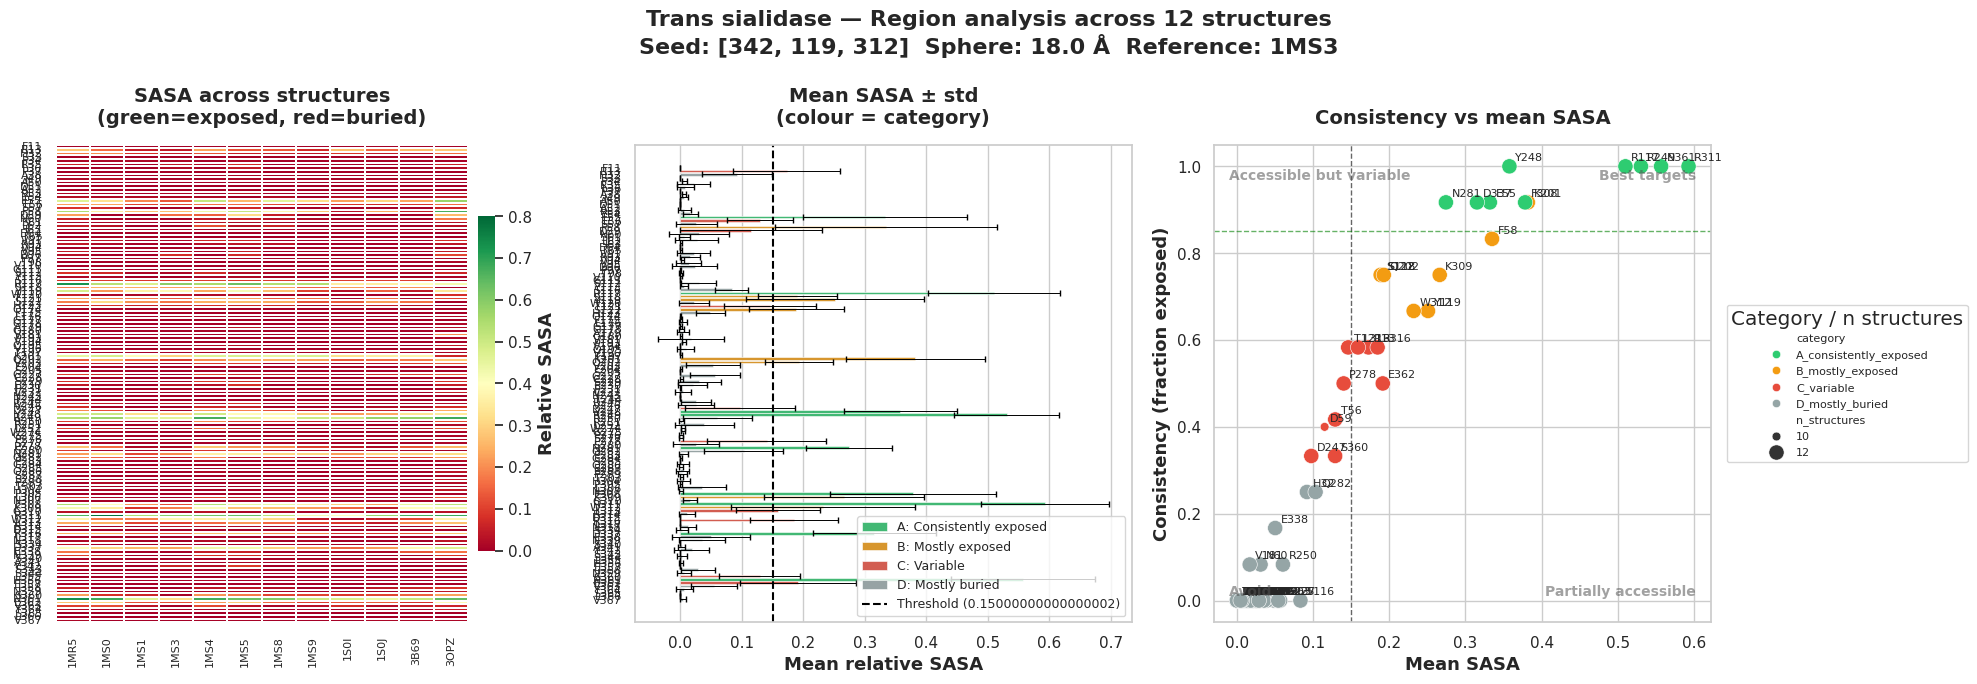

In [24]:
# Cell 11: Visualisation
# 
# Three panels:
# Left: heatmap of SASA values — structures x residues (the transition matrix)
# Centre: mean SASA bar chart for the region coloured by category
# Right: consistency vs mean SASA scatter

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

struct_names = list(structures.keys())
region_positions = sorted(region_data.keys())
residue_labels = [f"{region_data[p]['uniprot_residue']}{p}" for p in region_positions]

# Build heatmap matrix as a DataFrame (structures as columns, residues as index)
heatmap_data = np.zeros((len(region_positions), len(struct_names)))
for i, pos in enumerate(region_positions):
    for j, stem in enumerate(struct_names):
        heatmap_data[i, j] = region_data[pos]['per_structure'].get(stem, 0.0)

heatmap_data_df = pd.DataFrame(heatmap_data, index=residue_labels, columns=struct_names)

ax = axes[0]
sns.heatmap(
    heatmap_data_df,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=0.8,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Relative SASA', 'shrink': 0.7, 'pad': 0.02},
    xticklabels=True,
    yticklabels=True,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('SASA across structures\n(green=exposed, red=buried)',
             fontsize=14, fontweight='bold', pad=15)
cbar = ax.collections[0].colorbar
cbar.set_label('Relative SASA', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

# Centre panel: horizontal bar chart, hue = category
bar_df = pd.DataFrame({
    'residue':    residue_labels,
    'mean_sasa':  [region_data[p]['mean_sasa'] for p in region_positions],
    'std_sasa':   [region_data[p]['std_sasa'] for p in region_positions],
    'category':   [region_data[p]['category'] for p in region_positions],
})

ax2 = axes[1]
hue_order = [c for c in CATEGORY_SASA if c in bar_df['category'].unique()]
sns.barplot(
    data=bar_df, y='residue', x='mean_sasa', hue='category',
    order=residue_labels, hue_order=hue_order, palette=CATEGORY_SASA,
    dodge=False, edgecolor='white', linewidth=0.4, ax=ax2,
)
ax2.errorbar(
    bar_df['mean_sasa'], range(len(bar_df)),
    xerr=bar_df['std_sasa'], fmt='none', color='black', capsize=2, linewidth=0.7,
)
ax2.axvline(SASA_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold ({SASA_THRESHOLD})')
ax2.set_xlabel('Mean relative SASA', fontsize=13, fontweight='bold')
ax2.set_ylabel('')
ax2.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='x', labelsize=11)
ax2.set_title('Mean SASA ± std\n(colour = category)', fontsize=14, fontweight='bold', pad=15)

category_names = {
    'A_consistently_exposed': 'A: Consistently exposed',
    'B_mostly_exposed':       'B: Mostly exposed',
    'C_variable':             'C: Variable',
    'D_mostly_buried':        'D: Mostly buried',
    'missing':                'Missing',
}
handles, labels = ax2.get_legend_handles_labels()
clean_labels = [category_names.get(l, l) for l in labels]
ax2.legend(handles, clean_labels, fontsize=9, loc='lower right')

# Right panel: consistency vs mean SASA scatter
scatter_df = pd.DataFrame({
    'residue':      residue_labels,
    'mean_sasa':    [region_data[p]['mean_sasa'] for p in region_positions],
    'consistency':  [region_data[p]['consistency'] for p in region_positions],
    'category':     [region_data[p]['category'] for p in region_positions],
    'n_structures': [region_data[p]['n_structures'] for p in region_positions],
})

ax3 = axes[2]
sns.scatterplot(
    data=scatter_df, x='mean_sasa', y='consistency',
    hue='category', hue_order=hue_order, palette=CATEGORY_SASA,
    size='n_structures', sizes=(40, 120),
    edgecolor='white', linewidth=0.4, ax=ax3, zorder=3,
)
for _, row in scatter_df.iterrows():
    ax3.annotate(row['residue'], (row['mean_sasa'], row['consistency']),
                 fontsize=8, xytext=(4, 4), textcoords='offset points')

ax3.axvline(SASA_THRESHOLD, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax3.axhline(0.85, color='green', linestyle='--', linewidth=1, alpha=0.6)

quad_kwargs = dict(fontsize=10, fontweight='bold', alpha=0.55, color='#555555',
                    transform=ax3.transAxes)
ax3.text(0.97, 0.95, 'Best targets',              ha='right', va='top',    **quad_kwargs)
ax3.text(0.03, 0.95, 'Accessible but variable',   ha='left',  va='top',    **quad_kwargs)
ax3.text(0.97, 0.05, 'Partially accessible',      ha='right', va='bottom', **quad_kwargs)
ax3.text(0.03, 0.05, 'Avoid',                     ha='left',  va='bottom', **quad_kwargs)

ax3.set_xlabel('Mean SASA', fontsize=13, fontweight='bold')
ax3.set_ylabel('Consistency (fraction exposed)', fontsize=13, fontweight='bold')
ax3.tick_params(labelsize=11)
ax3.set_title('Consistency vs mean SASA', fontsize=14, fontweight='bold', pad=15)
ax3.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5),
           title='Category / n structures')

plt.suptitle(
    f'{TARGET_NAME} — Region analysis across {len(structures)} structures\n'
    f'Seed: {SEED_RESIDUES}  Sphere: {SPHERE_RADIUS} Å  '
    f'Reference: {REF_STRUCTURE}',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()

fig_path = output_dir / f'{TARGET_LABEL}_region_analysis.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
pass
print(f'Figure saved: {fig_path}')


In [25]:
# Cell 12: Save outputs for Notebook 01

output = {
    'target_name':         TARGET_NAME,
    'target_label':        TARGET_LABEL,
    'reference_structure': REF_STRUCTURE,
    'reference_chain':     REF_CHAIN,
    'seed_residues':       SEED_RESIDUES,
    'sphere_radius':       SPHERE_RADIUS,
    'sasa_threshold':      SASA_THRESHOLD,
    'n_structures':        len(structures),
    'structures':          list(structures.keys()),
    'global_max_sasa':     global_max_sasa,
    'region_canonical':    sorted(list(region_canonical)),
    'candidate_pool_A':    candidate_pool_00a,
    'region_data':         {str(k): v for k, v in region_data.items()},
    'contact_scores':      contact_scores_dict,
}

out_path = output_dir / f'{TARGET_LABEL}_consensus_sasa.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'NOTEBOOK 00a COMPLETE — {TARGET_NAME}')
print('=' * 60)
print(f'Structures  : {list(structures.keys())}')
print(f'Region size : {len(region_data)} residues')
print(f'Category A  : {len(candidate_pool_00a)} consistently exposed')
print(f'Output      : {out_path}')
print()
print(f'Candidate pool: {candidate_pool_00a}')
print()
print('FINAL VERIFICATION:')
rd = {str(k): v for k, v in region_data.items()}
for pdb_rn, expected, label in [(342,'Y','Tyr342'),(119,'Y','Tyr119'),(312,'W','Trp312')]:
    info = rd.get(str(pdb_rn), {})
    aa   = info.get('uniprot_residue', 'NOT FOUND')
    ok   = 'OK  ' if aa == expected else 'FAIL'
    print(f'  {ok}  {label}: pos {pdb_rn} = {aa} (expected {expected})')


NOTEBOOK 00a COMPLETE — Trans sialidase
Structures  : ['1MR5', '1MS0', '1MS1', '1MS3', '1MS4', '1MS5', '1MS8', '1MS9', '1S0I', '1S0J', '3B69', '3OPZ']
Region size : 132 residues
Category A  : 9 consistently exposed
Output      : /mnt/c/Antibody Design/ts_consensus_sasa.json

Candidate pool: [55, 117, 248, 249, 281, 308, 311, 337, 361]

FINAL VERIFICATION:
  OK    Tyr342: pos 342 = Y (expected Y)
  OK    Tyr119: pos 119 = Y (expected Y)
  OK    Trp312: pos 312 = W (expected W)
